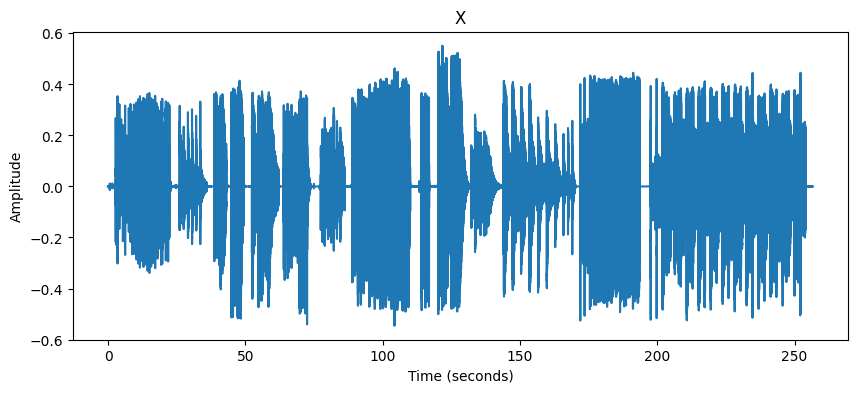

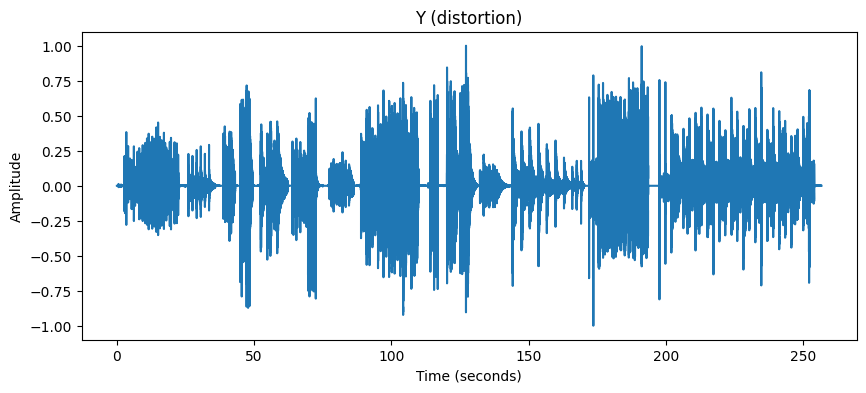

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def load_wav(path, sr=22050):
    audio, sample_rate = librosa.load(path, sr=sr)  # mono by default
    return audio, sample_rate

def plot_waveform(audio, title, sr):
    time = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.figure(figsize=(10, 4))
    plt.plot(time, audio)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    #plt.xlim(10, 10.01)  # show only 0–1 seconds
    plt.ylabel("Amplitude")
    plt.show()

# Example
audio, sr = load_wav("Data/ML Guitar_ Target_Data.wav")
plot_waveform(audio, "X", sr)
audio, sr = load_wav("Data/ML Guitar_ Initial_Data.wav")
plot_waveform(audio, "Y (distortion)", sr)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import librosa
import soundfile as sf
import time
import copy
import optuna
import json
import os

# =====================================================================
# Config  (fixed values; tunables live in the search space below)
# =====================================================================
class Config:
    sr          = 44100  
    batch_size  = 32
    layers      = 1
    block       = 512
    # ... rest unchanged ...
    # ---- HP search / training budget ----
    n_trials        = 25       # Bayesian trials
    epochs_search   = 6        # short budget per trial (pruner kills bad ones early)
    steps_search    = 80       # fewer steps during search
    epochs_final    = 40       # longer run for the winning config
    steps_final     = 120
    patience        = 6        # early stopping for the final run

    study_name   = "distortion_gru"
    storage_path = "sqlite:///hp_study.db"     # persistent Optuna DB
    best_hp_path = "best_hp.json"              # human-readable best config

cfg = Config()

# =====================================================================
# Data loading
# =====================================================================
def load_wav(path, sr):
    audio, _ = librosa.load(path, sr=sr)
    return audio.astype(np.float32)

def prepare_data():
    print("Loading audio...")
    y = load_wav("Data/ML Guitar_ Initial_Data.wav", cfg.sr)
    x = load_wav("Data/ML Guitar_ Target_Data.wav",  cfg.sr)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    print(f"  {n:,} samples  ({n/cfg.sr:.1f}s @ {cfg.sr} Hz)")

    # 80% train / 10% validation / 10% test
    i_tr = int(0.8 * n)
    i_va = int(0.9 * n)
    x_tr, x_va, x_te = x[:i_tr], x[i_tr:i_va], x[i_va:]
    y_tr, y_va, y_te = y[:i_tr], y[i_tr:i_va], y[i_va:]

    # peak-normalize using TRAIN peaks only
    peak_x = np.max(np.abs(x_tr)) + 1e-8
    peak_y = np.max(np.abs(y_tr)) + 1e-8
    x_tr, x_va, x_te = x_tr / peak_x, x_va / peak_x, x_te / peak_x
    y_tr, y_va, y_te = y_tr / peak_y, y_va / peak_y, y_te / peak_y

    print(f"  Train: {len(x_tr):,}  Val: {len(x_va):,}  Test: {len(x_te):,}")
    return (x_tr, y_tr, x_va, y_va, x_te, y_te), (peak_x, peak_y)

# =====================================================================
# Model
# =====================================================================
class DistortionGRU(nn.Module):
    def __init__(self, hidden, layers=cfg.layers):
        super().__init__()
        self.gru = nn.GRU(1, hidden, layers, batch_first=True)
        self.fc  = nn.Linear(hidden, 1)

    def forward(self, x, state=None):
        out, state = self.gru(x, state)
        out = self.fc(out)
        return out, state

# =====================================================================
# Loss
# =====================================================================
def pre_emphasis(x, coeff):
    return x[:, 1:, :] - coeff * x[:, :-1, :]

def esr_loss(pred, target, coeff, eps=1e-8):
    pe_pred   = pre_emphasis(pred, coeff)
    pe_target = pre_emphasis(target, coeff)
    num = torch.sum((pe_pred - pe_target) ** 2)
    den = torch.sum(pe_target ** 2) + eps
    return num / den

# =====================================================================
# Batch sampler
# =====================================================================
def sample_batch(x, y, seq_len, device):
    n = len(x)
    starts = torch.randint(0, n - seq_len, (cfg.batch_size,))
    offs   = torch.arange(seq_len)
    idx    = starts.unsqueeze(1) + offs.unsqueeze(0)
    xb = x[idx].unsqueeze(-1).to(device)
    yb = y[idx].unsqueeze(-1).to(device)
    return xb, yb

# =====================================================================
# Generic training loop (used by both search and final run)
#   - reports per-epoch test ESR
#   - if `trial` is given, supports Optuna pruning + early stopping
#   - returns (best_test_loss, best_state_dict)
# =====================================================================
def run_training(hp, data, device, epochs, steps,
                 trial=None, patience=None, verbose=False):
    x_tr, y_tr, x_va, y_va, x_te, y_te = data      # unpack 6
    x_tr = torch.from_numpy(x_tr)
    y_tr = torch.from_numpy(y_tr)
    # We optimize/early-stop against VALIDATION here. Test is never used.
    x_va = torch.from_numpy(x_va).unsqueeze(0).unsqueeze(-1).to(device)
    y_va = torch.from_numpy(y_va).unsqueeze(0).unsqueeze(-1).to(device)

    model = DistortionGRU(hidden=hp["hidden"]).to(device)
    opt = torch.optim.Adam(model.parameters(),
                           lr=hp["lr"], weight_decay=hp["weight_decay"])

    best_loss  = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        for _ in range(steps):
            xb, yb = sample_batch(x_tr, y_tr, hp["seq_len"], device)
            pred, _ = model(xb)
            warmup = hp["seq_len"] // 8
            loss = esr_loss(pred[:, warmup:], yb[:, warmup:], hp["pre_emph"])
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # --- VALIDATION ESR (drives best-model selection + pruning) ---
        model.eval()
        with torch.no_grad():
            pred, _ = model(x_va)
            val_loss = esr_loss(pred, y_va, hp["pre_emph"]).item()

        if val_loss < best_loss - 1e-4:
            best_loss  = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            flag = "  <-- best"
        else:
            wait += 1
            flag = ""

        if verbose:
            print(f"  Epoch {epoch+1:2d}/{epochs}  "
                  f"val ESR={val_loss:.4f}  ({time.time()-t0:.1f}s){flag}")

        if trial is not None:
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if patience is not None and wait >= patience:
            if verbose:
                print(f"  Early stop. Best val ESR={best_loss:.4f}")
            break

    return best_loss, best_state

# =====================================================================
# Optuna objective
# =====================================================================
def make_objective(data, device):
    def objective(trial):
        hp = {
            "lr"          : trial.suggest_float("lr", 1e-3, 2e-2, log=True),
            "hidden"      : trial.suggest_categorical("hidden", [16, 24, 32, 48]),
            "seq_len"     : trial.suggest_categorical("seq_len", [128, 256, 512]),
            "pre_emph"    : trial.suggest_float("pre_emph", 0.7, 0.95),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        }
        best_loss, _ = run_training(
            hp, data, device,
            epochs=cfg.epochs_search,
            steps=cfg.steps_search,
            trial=trial,
        )
        return best_loss
    return objective

# =====================================================================
# Streaming / bench / analysis  (unchanged logic, just take hp where needed)
# =====================================================================
def stream_audio(model, peaks, input_device=None, output_device=None):
    import sounddevice as sd
    torch.set_num_threads(1)
    peak_x, peak_y = peaks
    in_scale  = 1.0 / peak_x
    out_scale = peak_y
    model = model.to("cpu").eval()

    with torch.no_grad():
        h = None
        for _ in range(5):
            _, h = model(torch.zeros(1, cfg.block, 1), h)

    state = {"h": None}

    @torch.no_grad()
    def callback(indata, outdata, frames, time_info, status):
        x = torch.from_numpy(indata[:, 0]).view(1, -1, 1) * in_scale
        y, state["h"] = model(x, state["h"])
        outdata[:, 0] = (y.view(-1) * out_scale).numpy()

    try:
        with sd.Stream(
            device=(input_device, output_device),
            channels=1, samplerate=cfg.sr, blocksize=cfg.block,
            latency="high", dtype="float32", callback=callback,
        ):
            print(f"\nLive @ {cfg.sr} Hz, block {cfg.block} "
                  f"({cfg.block/cfg.sr*1000:.1f} ms). Press Enter to stop.")
            input()
    except sd.PortAudioError as e:
        print(f"\n[Audio error] {e}")
        print(sd.query_devices())

@torch.no_grad()
def bench(model, n=100):
    model = model.to("cpu").eval()
    x = torch.zeros(1, cfg.block, 1)
    h = None
    y, h = model(x, h)
    t0 = time.perf_counter()
    for _ in range(n):
        y, h = model(x, h)
    dt = (time.perf_counter() - t0) / n
    budget = cfg.block / cfg.sr * 1000
    print(f"\n{dt*1000:.2f} ms/block   (budget {budget:.1f} ms)   "
          f"{'OK' if dt*1000 < budget else 'TOO SLOW'}")

@torch.no_grad()
def render_test(model, data, peaks, device):
    x_tr, y_tr, x_va, y_va, x_te, y_te = data
    peak_x, peak_y = peaks
    model.eval()
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    sf.write("predicted_distortion.wav", pred * peak_y, cfg.sr)
    sf.write("test_input_clean.wav",     x_te * peak_x, cfg.sr)
    sf.write("test_target_true.wav",     y_te * peak_y, cfg.sr)
    print("\nSaved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav")
def load_best_hp():
    """Load best HPs from JSON if it exists, else return None."""
    if not os.path.exists(cfg.best_hp_path):
        return None
    with open(cfg.best_hp_path) as f:
        record = json.load(f)
    print(f"Loaded best HPs from {cfg.best_hp_path} "
          f"(search ESR={record['search_esr']:.4f})")
    return record["params"]


In [3]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
data, peaks = prepare_data()

# Toggle: force a fresh search even if best_hp.json exists.
FORCE_SEARCH = False

best = None if FORCE_SEARCH else load_best_hp()

Device: cpu
Loading audio...
  11,316,887 samples  (256.6s @ 44100 Hz)
  Train: 9,053,509  Val: 1,131,689  Test: 1,131,689


In [4]:

# ------------------------------------------------------------------
# Hyperparameter search (only if we don't already have best HPs)
# ------------------------------------------------------------------
if best is None:
    print(f"\n=== Hyperparameter search ===")

    study = optuna.create_study(
        study_name=cfg.study_name,
        storage=cfg.storage_path,          # persists to SQLite file
        load_if_exists=True,               # resume if DB already exists
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=0),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
    )
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Only run more trials if we haven't reached the target count yet.
    done = len([t for t in study.trials
                if t.state in (optuna.trial.TrialState.COMPLETE,
                               optuna.trial.TrialState.PRUNED)])
    remaining = max(0, cfg.n_trials - done)
    if remaining > 0:
        print(f"  {done} trials already in DB, running {remaining} more "
              f"(target {cfg.n_trials})...")
        study.optimize(make_objective(data, device), n_trials=remaining,
                       show_progress_bar=True)
    else:
        print(f"  {done} trials already in DB (target {cfg.n_trials} reached). "
              f"Skipping search.")

    best = study.best_params
    print("\n=== Best hyperparameters ===")
    for k, v in best.items():
        print(f"  {k:13s}: {v}")
    print(f"  best search ESR: {study.best_value:.4f}")

    # ---------- Save best HPs to JSON ----------
    best_record = {
        "params"    : best,
        "search_esr": study.best_value,
        "n_trials"  : done + remaining,
        "fixed"     : {
            "sr"        : cfg.sr,
            "batch_size": cfg.batch_size,
            "layers"    : cfg.layers,
        },
    }
    with open(cfg.best_hp_path, "w") as f:
        json.dump(best_record, f, indent=2)
    print(f"  Saved best HPs -> {cfg.best_hp_path}")


=== Hyperparameter search ===


[I 2026-06-04 02:31:42,651] A new study created in RDB with name: distortion_gru


  0 trials already in DB, running 25 more (target 25)...


  0%|          | 0/25 [00:00<?, ?it/s]


=== Best hyperparameters ===
  lr           : 0.019486991655375763
  hidden       : 48
  seq_len      : 512
  pre_emph     : 0.7356070946600158
  weight_decay : 2.9696608825156744e-06
  best search ESR: 0.1159
  Saved best HPs -> best_hp.json


In [5]:
# ------------------------------------------------------------------
# Final training with best HPs (longer run + early stopping)
# ------------------------------------------------------------------
print("\n=== Final training with best config ===")
hp = {
    "lr"          : best["lr"],
    "hidden"      : best["hidden"],
    "seq_len"     : best["seq_len"],
    "pre_emph"    : best["pre_emph"],
    "weight_decay": best["weight_decay"],
}
best_loss, best_state = run_training(
    hp, data, device,
    epochs=cfg.epochs_final, steps=cfg.steps_final,
    patience=cfg.patience, verbose=True,
)
print(f"\nFinal best val ESR = {best_loss:.4f}")


=== Final training with best config ===
  Epoch  1/40  val ESR=0.4131  (22.2s)  <-- best
  Epoch  2/40  val ESR=0.3159  (22.6s)  <-- best
  Epoch  3/40  val ESR=0.2659  (21.8s)  <-- best
  Epoch  4/40  val ESR=0.1254  (21.5s)  <-- best
  Epoch  5/40  val ESR=0.1882  (21.9s)
  Epoch  6/40  val ESR=0.1591  (21.6s)
  Epoch  7/40  val ESR=0.1955  (23.3s)
  Epoch  8/40  val ESR=0.1686  (21.6s)
  Epoch  9/40  val ESR=0.1021  (22.0s)  <-- best
  Epoch 10/40  val ESR=0.1306  (22.1s)
  Epoch 11/40  val ESR=0.1279  (23.3s)
  Epoch 12/40  val ESR=0.1052  (22.4s)
  Epoch 13/40  val ESR=0.1222  (22.2s)
  Epoch 14/40  val ESR=0.1499  (23.8s)
  Epoch 15/40  val ESR=0.1081  (23.0s)
  Early stop. Best val ESR=0.1021

Final best val ESR = 0.1021


In [6]:
# rebuild model with winning architecture and load best weights
model = DistortionGRU(hidden=hp["hidden"]).to(device)
model.load_state_dict(best_state)

# ---------- FINAL, UNBIASED evaluation on the held-out TEST set ----------
# (the test set was never used for tuning or early stopping)
x_te_t = torch.from_numpy(data[4]).unsqueeze(0).unsqueeze(-1).to(device)
y_te_t = torch.from_numpy(data[5]).unsqueeze(0).unsqueeze(-1).to(device)
model.eval()
with torch.no_grad():
    pred, _ = model(x_te_t)
    final_test_esr = esr_loss(pred, y_te_t, hp["pre_emph"]).item()
print(f"\n*** Final TEST ESR (held-out)   = {final_test_esr:.4f} ***")
print(f"    (best VALIDATION ESR was      = {best_loss:.4f})")

# ---------- Save trained model ----------
torch.save({
    "state_dict": best_state,
    "hp"        : hp,
    "peaks"     : peaks,
    "val_esr"   : best_loss,        # selection metric
    "test_esr"  : final_test_esr,   # honest, untouched metric
}, "distortion_model.pt")
print("Saved trained model -> distortion_model.pt")


*** Final TEST ESR (held-out)   = 0.1054 ***
    (best VALIDATION ESR was      = 0.1021)
Saved trained model -> distortion_model.pt


In [7]:

# ---------- Outputs ----------
render_test(model, data, peaks, device)
bench(model)


Saved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav

5.67 ms/block   (budget 11.6 ms)   OK


In [8]:
stream_audio(model, peaks)


Live @ 44100 Hz, block 512 (11.6 ms). Press Enter to stop.



================ Full test-set metrics ================
Test samples                  : 1,131,689 (25.7s)
ESR (whole test set)          : 0.1063
Worst 0.1% deviations (1,131 samples)
  mean |error| (normalized)   : 0.2068
  mean |error| (output scale) : 0.2065
Saved plot: segment_analysis.png


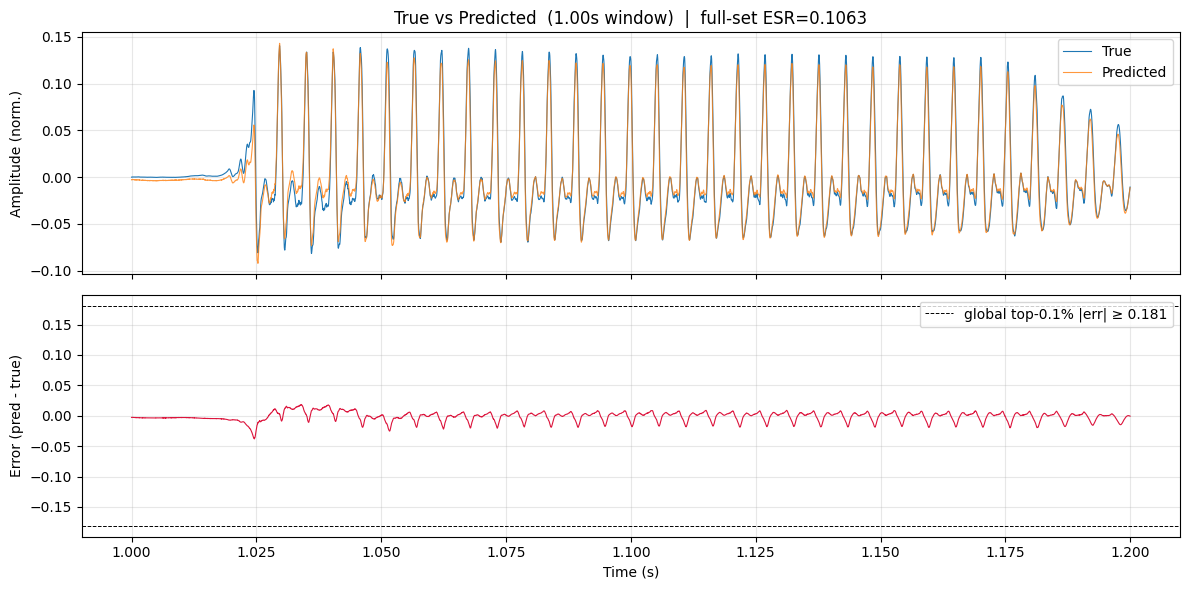

In [10]:
import matplotlib.pyplot as plt

@torch.no_grad()
def analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=1.0):
    x_tr, y_tr, x_va, y_va, x_te, y_te = data      # unpack 6
    peak_x, peak_y = peaks
    model.eval()

    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    true = y_te
    # ... rest of the function is IDENTICAL ...

    # ================== METRICS: full test set ==================
    err = pred - true
    esr = np.sum(err ** 2) / (np.sum(true ** 2) + 1e-8)

    abs_err = np.abs(err)
    n_top = max(1, int(0.001 * len(abs_err)))     # top 0.1%
    worst = np.sort(abs_err)[-n_top:]
    worst_mean = worst.mean()

    print("\n================ Full test-set metrics ================")
    print(f"Test samples                  : {len(true):,} "
          f"({len(true)/cfg.sr:.1f}s)")
    print(f"ESR (whole test set)          : {esr:.4f}")
    print(f"Worst 0.1% deviations ({n_top:,} samples)")
    print(f"  mean |error| (normalized)   : {worst_mean:.4f}")
    print(f"  mean |error| (output scale) : {worst_mean * peak_y:.4f}")
    print("=======================================================")

    # ================== PLOT: chosen window only ==================
    a = int(plot_start_sec * cfg.sr)
    b = a + int(plot_dur_sec * cfg.sr)
    b = min(b, len(true))
    a = max(0, min(a, b - 1))

    true_w = true[a:b]
    pred_w = pred[a:b]
    err_w  = err[a:b]
    t = np.arange(len(true_w)) / cfg.sr + a / cfg.sr   # absolute time (s)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(t, true_w, label="True",      linewidth=0.8)
    ax1.plot(t, pred_w, label="Predicted", linewidth=0.8, alpha=0.8)
    ax1.set_ylabel("Amplitude (norm.)")
    ax1.set_title(f"True vs Predicted  ({plot_start_sec:.2f}s window)  |  "
                  f"full-set ESR={esr:.4f}")
    ax1.legend(loc="upper right")
    ax1.grid(alpha=0.3)

    ax2.plot(t, err_w, color="crimson", linewidth=0.8)
    # threshold is taken from the WHOLE test set (so it's meaningful globally)
    thresh = worst.min()
    ax2.axhline( thresh, color="k", linestyle="--", linewidth=0.7,
                 label=f"global top-0.1% |err| ≥ {thresh:.3f}")
    ax2.axhline(-thresh, color="k", linestyle="--", linewidth=0.7)
    ax2.set_ylabel("Error (pred - true)")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc="upper right")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("segment_analysis.png", dpi=120)
    print("Saved plot: segment_analysis.png")
    plt.show()
analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=0.2)
